In [1]:
import os
import ROOT

Welcome to JupyROOT 6.20/00


In [2]:
tp = "devel"
tp = "prod"
if tp == "prod":
    ROOT.ROOT.EnableImplicitMT()

In [3]:
ROOT.gSystem.AddDynamicPath('/opt/exp_software/neutrino/EDEPSIM/lib/')
ROOT.gSystem.Load('libedepsim_io.so')
ROOT.gInterpreter.AddIncludePath('/opt/exp_software/neutrino/EDEPSIM/include/EDepSim')
ROOT.gInterpreter.ProcessLine('#include <TG4Event.h>')
ROOT.gInterpreter.ProcessLine('#include "utils.cpp"')

0

In [4]:
path_prod = "/storage/gpfs_data/neutrino/users/mt/ANA/spill_slicing/productions"
name_prod = "SAND_SPILL"
n_files = 10

# Get the list of files
def list_files_with_extensions(path, name, n_files, extension):
    lst = []
    for i in range(n_files):
        path_folder = os.path.join(path,name,name + "_" + str(i))
        for fname in os.listdir(path_folder):
            if fname.endswith(extension):
                lst.append(os.path.join(path_folder,fname))
    return lst

lst_gtrac = list_files_with_extensions(path_prod,name_prod,n_files,".gtrac.root")
lst_edep = list_files_with_extensions(path_prod,name_prod,n_files,".edep.root")

In [5]:
# Having a look at the variables in the TTree
f = ROOT.TFile(lst_gtrac[0])
t = f.Get("gRooTracker")
# t.Print()

In [6]:
# Read GENIE gtrac as TChain and RDataFrane
t_gen = ROOT.TChain("gRooTracker","GENIE")
t_edp = ROOT.TChain("EDepSimEvents","EDEPSIM")

for fle in lst_gtrac:
    t_gen.AddFile(fle)
    
for fle in lst_edep:
    t_edp.AddFile(fle)

df_gen = ROOT.RDataFrame(t_gen)
df_edp = ROOT.RDataFrame(t_edp)

# for col_name in df.GetColumnNames():
#     print(col_name)

In [7]:
# Total number of spill
# Total number of interactions

if tp != "prod":
    df_edp = df_edp.Range(0,20)

df_edp = df_edp.Define("spill_id","get_spill_id()")
df_edp = df_edp.Define("event_n","Event.Primaries.size()")
df_edp = df_edp.Define("event_x","my_event_processing(Event, get_event_primaries, get_primary_x)")
df_edp = df_edp.Define("event_y","my_event_processing(Event, get_event_primaries, get_primary_y)")
df_edp = df_edp.Define("event_z","my_event_processing(Event, get_event_primaries, get_primary_z)")
df_edp = df_edp.Define("event_t","my_event_processing(Event, get_event_primaries, get_primary_t)")
df_edp = df_edp.Define("event_dt","get_dt_between_interactions(Event)")
df_edp = df_edp.Define("my_hits","fill_myHitSegments(Event, spill_id)")
df_edp = df_edp.Define("hits_ecal_evId","my_event_processing(Event, get_ecal_hit_segments, get_eventid_of_hit)")
df_edp = df_edp.Define("hits_ecal_x","my_event_processing(Event, get_ecal_hit_segments, get_hit_x)")
df_edp = df_edp.Define("hits_ecal_y","my_event_processing(Event, get_ecal_hit_segments, get_hit_y)")
df_edp = df_edp.Define("hits_ecal_z","my_event_processing(Event, get_ecal_hit_segments, get_hit_z)")
df_edp = df_edp.Define("hits_ecal_t","my_event_processing(Event, get_ecal_hit_segments, get_hit_t)")
df_edp = df_edp.Define("hits_drft_evId","my_event_processing(Event, get_drft_hit_segments, get_eventid_of_hit)")
df_edp = df_edp.Define("hits_drft_x","my_event_processing(Event, get_drft_hit_segments, get_hit_x)")
df_edp = df_edp.Define("hits_drft_y","my_event_processing(Event, get_drft_hit_segments, get_hit_y)")
df_edp = df_edp.Define("hits_drft_z","my_event_processing(Event, get_drft_hit_segments, get_hit_z)")
df_edp = df_edp.Define("hits_drft_t","my_event_processing(Event, get_drft_hit_segments, get_hit_t)")

In [ ]:
# df_edp = df_edp.Range(0, 20)

h_spill_id = df_edp.Histo1D(("h_spill_id", "spill id", 25, 0, 25),"spill_id")
h_event_n = df_edp.Histo1D(("h_event_n", "n. of interactions per spill", 45, 40, 130),"event_n")
h_event_x = df_edp.Histo1D(("h_event_x", "X of interactions", 100, -3500, 3500),"event_x")
h_event_y = df_edp.Histo1D(("h_event_y", "Y of interactions", 100, -6000, 1000),"event_y")
h_event_z = df_edp.Histo1D(("h_event_z", "Z of interactions", 100, 20000, 28000),"event_z")
h_event_t = df_edp.Histo1D(("h_event_t", "T of interactions", 100, 0, 12000),"event_t")
h_event_zy = df_edp.Histo2D(("h_event_zy", "ZY of interactions", 100, 20000, 28000, 100, -6000, 1000),"event_z", "event_y")
h_event_dt = df_edp.Histo1D(("h_event_dt", "DT of interactions", 100, 0, 1000),"event_dt")
h_hits_ecal_t = df_edp.Histo1D(("h_hits_ecal_t", "T of EMCalSci hits", 100, 0, 12000),"hits_ecal_t")
h_hits_drft_t = df_edp.Histo1D(("h_hits_drft_t", "T of DriftVolume hits", 100, 0, 12000),"hits_drft_t")

n_spl = df_edp.Count()
n_int = df_edp.Sum("event_n")

print(f"Total number of spill: {n_spl.GetValue()}")
print(f"Total number of interactions: {int(n_int.GetValue())}")
print(f"Mean number of interactions per spill: {n_int.GetValue()/n_spl.GetValue():.1f}")

Total number of spill: 2400
Total number of interactions: 203861
Mean number of interactions per spill: 84.9


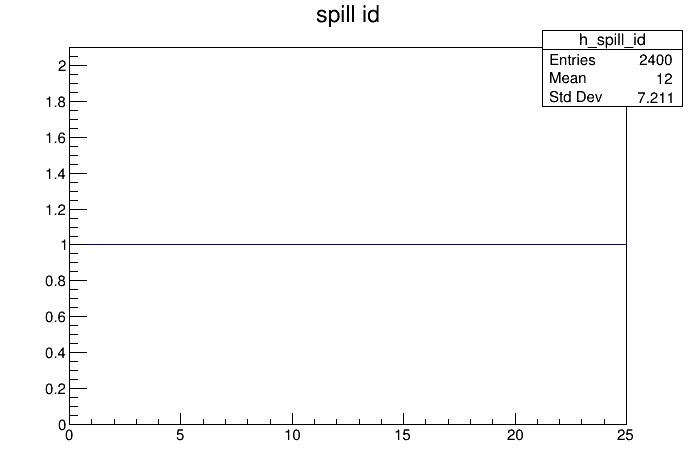

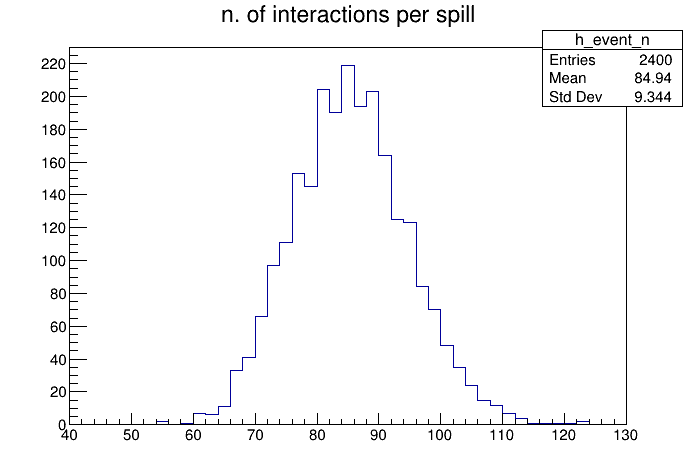

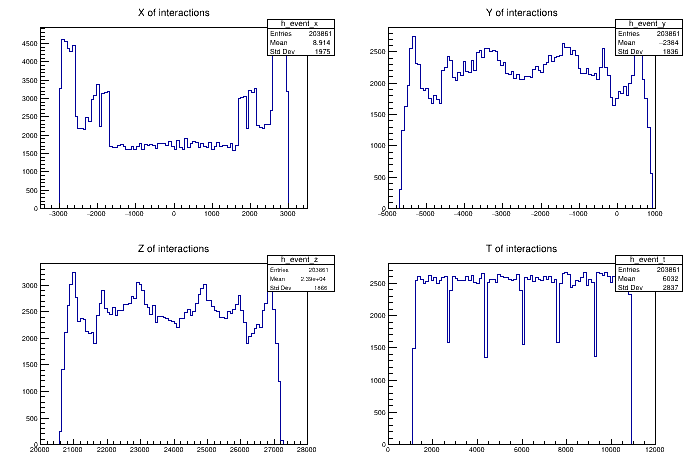

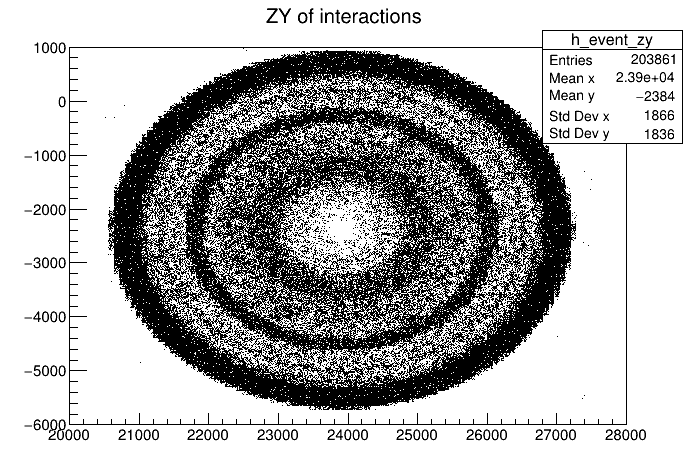

In [ ]:
c = ROOT.TCanvas()
h_spill_id.Draw()
c.Draw()
cn = ROOT.TCanvas()
h_event_n.Draw()
cn.Draw()
cxyzt = ROOT.TCanvas()
cxyzt.Divide(2,2)
cxyzt.cd(1)
h_event_x.Draw()
cxyzt.cd(2)
h_event_y.Draw()
cxyzt.cd(3)
h_event_z.Draw()
cxyzt.cd(4)
h_event_t.Draw()
cxyzt.Draw()
czy = ROOT.TCanvas()
h_event_zy.Draw()
czy.Draw()

mean dt between consecutive interactions: 113.6 ns


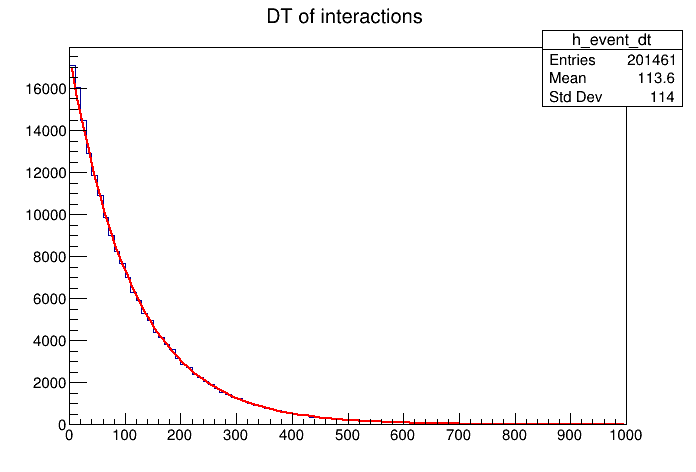

In [ ]:
fp = ROOT.TF1("fp","[0] * TMath::Exp(-x/[1])",0,1000)
fp.SetParameters(200, 100)
c = ROOT.TCanvas()
h_event_dt.Draw()
r = h_event_dt.Fit("fp","SQ")
c.Draw()

mu = r.Parameter(1)
print(f"mean dt between consecutive interactions: {mu:.1f} ns")

mean dt: 116.1


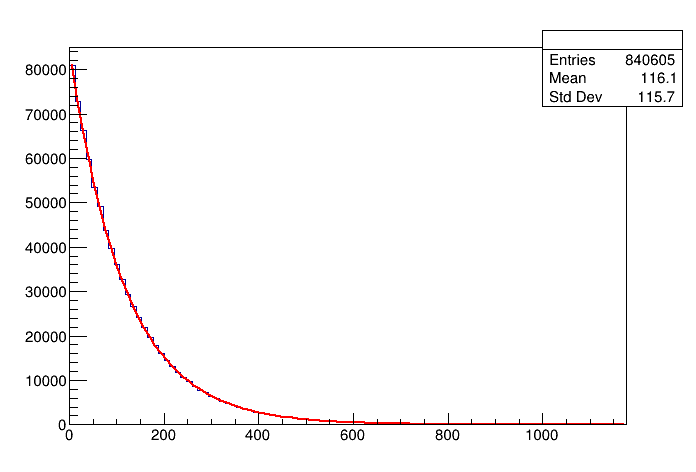

In [ ]:
import numpy as np
times = 10000
mean_n_ev = 85
time_window = 10000

def nev():
    global mean_n_ev
    return np.random.poisson(lam = mean_n_ev, size = 1)[0]

def ev_t(n_ev):
    global time_window
    return np.random.uniform(0, time_window, n_ev)

def ev_dt(ev_time):
    ev_time_sorted = np.sort(ev_time)
    return ev_time_sorted[1:] - ev_time_sorted[:-1]

ev_dtime = []
for i in range(times):
    ev_dtime.extend(ev_dt(ev_t(nev())))

n = len(ev_dtime) + 1
k = time_window/mean_n_ev

binning = (100,0,10 * time_window/mean_n_ev)
bin_w = (binning[2] - binning[1]) / binning[0]

h = ROOT.TH1D("","",binning[0],binning[1],binning[2])

for dt in ev_dtime:
    h.Fill(dt)

fp = ROOT.TF1("fp","[0] * TMath::Exp(-x/[1])",binning[1],binning[2])
fp.SetParameters(n/k*bin_w, k)

c = ROOT.TCanvas()
h.Draw()
r = h.Fit("fp","SQ")
c.Draw()


mu = r.Parameter(1)
print(f"mean dt: {mu:.1f}")

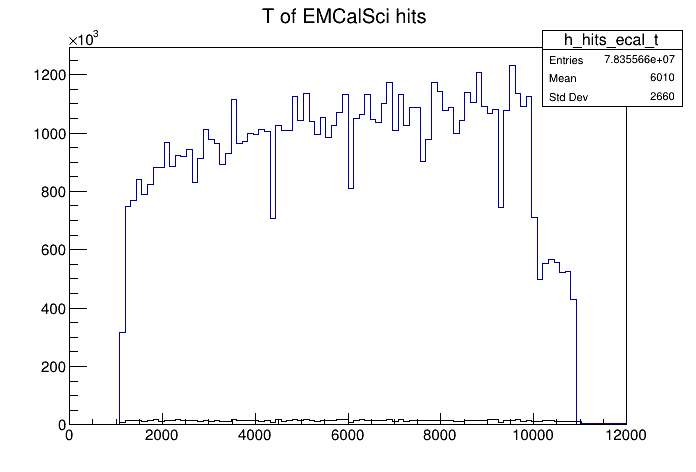

In [ ]:
c = ROOT.TCanvas()
h_hits_ecal_t.Draw()
h_hits_drft_t.SetLineColor(ROOT.kBlack)
h_hits_drft_t.Draw("SAME")
c.Draw()